# Labeling Dengan Indobert Model w11wo/indonesian-roberta-base-sentiment-classifier

Pemrosesan teks Kelompok 4
1. Bima Setia Sugiharto (24031554040)
2. Muhammad Geralldo Agatha Saputra (24031554091)
3. Moh. Rasya Al Khalifi (24031554132)


In [179]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC

import nltk
nltk.download("punkt")
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from wordcloud import WordCloud


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [180]:
df = pd.read_csv("hasil_stemming.csv")
df

,message_clean
0,halo mpl
1,tidak sesuai jadwal
2,it s onic time
3,NaN
4,jam paling lambat jam malalter egom haha
...,...
4694,jam berapa main
4695,anjay rame banget
4696,bismillahirrahmanirrahim allah yok
4697,er er qi main jam berapa bang


In [181]:
df.dropna(subset=['message_clean'], inplace=True)
df['message_clean'] = df['message_clean'].astype(str)
df

,message_clean
0,halo mpl
1,tidak sesuai jadwal
2,it s onic time
4,jam paling lambat jam malalter egom haha
5,jantidakn bahas tidak
...,...
4694,jam berapa main
4695,anjay rame banget
4696,bismillahirrahmanirrahim allah yok
4697,er er qi main jam berapa bang


In [182]:
klasifikasi = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")
def prediksi_sentimen(teks):
    hasil = klasifikasi(teks)
    return hasil[0]["label"]
df['sentimen'] = df["message_clean"].apply(prediksi_sentimen)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [183]:
jumlah_sentimen = df.sentimen.value_counts()
jumlah_sentimen

,count
sentimen,
negative,2212
positive,1270
neutral,1122


/tmp/ipython-input-1891154076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimen', data=df, palette='Set1')


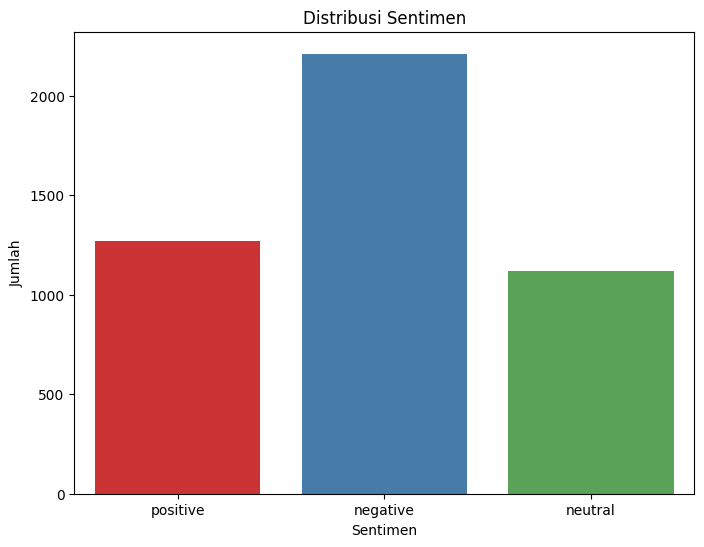

In [184]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sentimen', data=df, palette='Set1')
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

In [185]:
negative = ' '.join(df[df['sentimen'] == 'negative']['message_clean'].astype(str))
neutral = ' '.join(df[df['sentimen'] == 'neutral']['message_clean'].astype(str))
positive = ' '.join(df[df['sentimen'] == 'positive']['message_clean'].astype(str))

sentiment_texts = {
    'Negative': negative,
    'Neutral': neutral,
    'Positive': positive
}
# df.to_csv("hasil_labeling_Model 1.csv", index=False)

# Visualisasi Data

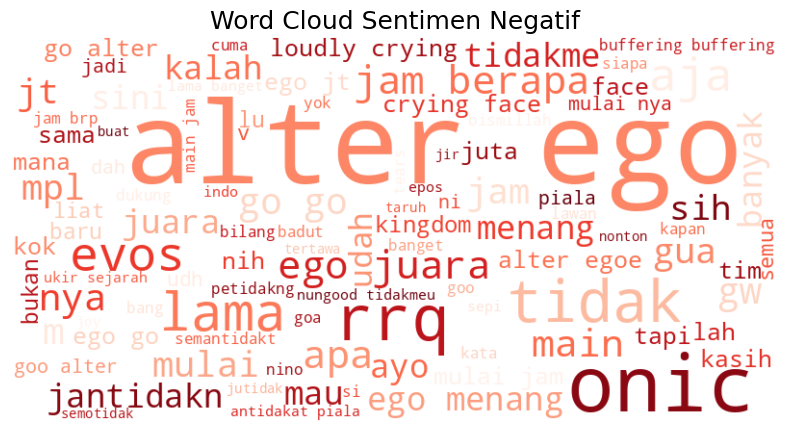

In [186]:
# wordcloud sentimen negatif
wordcloud_negatif = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(negative)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negatif, interpolation='bilinear')
plt.title('Word Cloud Sentimen Negatif', fontsize=18)
plt.axis('off')
plt.show()

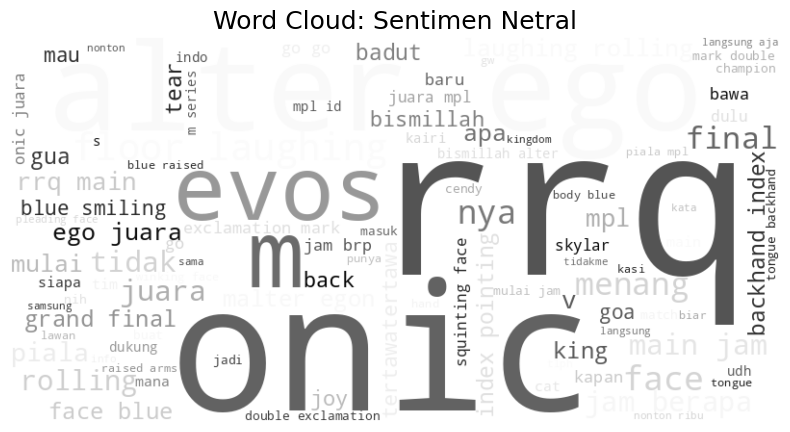

In [187]:
# wordcloud netral
wordcloud_netral = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greys',
    max_words=100
).generate(neutral)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_netral, interpolation='bilinear')
plt.title('Word Cloud: Sentimen Netral', fontsize=18)
plt.axis('off')
plt.show()

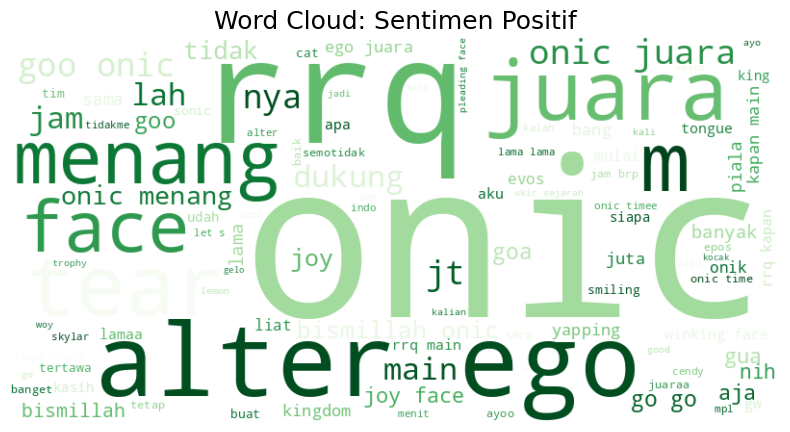

In [188]:
# wordcloud positif
wordcloud_positif = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positif, interpolation='bilinear')
plt.title('Word Cloud: Sentimen Positif', fontsize=18)
plt.axis('off')
plt.show()

# Pemodelan SVM

In [189]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
tvec = TfidfVectorizer()
X = df['message_clean']
y = df['sentimen']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_svm = Pipeline([
    ('vectorizer', tvec),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

model_svm.fit(X_train, y_train)
y_pred = model_svm.predict(X_test)
print(classification_report(y_test, model_svm.predict(X_test)))

              precision    recall  f1-score   support

    negative       0.67      0.83      0.74       432
     neutral       0.61      0.41      0.49       227
    positive       0.67      0.60      0.63       262

    accuracy                           0.66       921
   macro avg       0.65      0.61      0.62       921
weighted avg       0.66      0.66      0.65       921



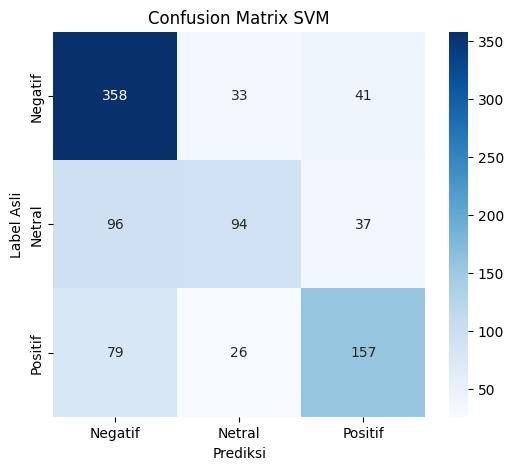

In [190]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif', 'Netral', 'Positif'],
    yticklabels=['Negatif', 'Netral', 'Positif']
)
plt.xlabel('Prediksi')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix SVM')
plt.show()

# Perbandingan Model untuk Model Indobert mdhugol/indonesia-bert-sentiment-classification

In [191]:
df = pd.read_csv("hasil_stemming.csv")
df

,message_clean
0,halo mpl
1,tidak sesuai jadwal
2,it s onic time
3,NaN
4,jam paling lambat jam malalter egom haha
...,...
4694,jam berapa main
4695,anjay rame banget
4696,bismillahirrahmanirrahim allah yok
4697,er er qi main jam berapa bang


In [192]:
df.dropna(subset=['message_clean'], inplace=True)
df['message_clean'] = df['message_clean'].astype(str)
df

,message_clean
0,halo mpl
1,tidak sesuai jadwal
2,it s onic time
4,jam paling lambat jam malalter egom haha
5,jantidakn bahas tidak
...,...
4694,jam berapa main
4695,anjay rame banget
4696,bismillahirrahmanirrahim allah yok
4697,er er qi main jam berapa bang


In [193]:
pretrained_name = "mdhugol/indonesia-bert-sentiment-classification"
tokenizer = AutoTokenizer.from_pretrained(pretrained_name)
model = AutoModelForSequenceClassification.from_pretrained(pretrained_name)
klasifikasi = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=-1)

def prediksi_sentimen(teks):
    hasil = klasifikasi(teks)
    return hasil[0]["label"]
df['sentimen'] = df["message_clean"].apply(prediksi_sentimen)

label_map = {
    'LABEL_0': 'positif',
    'LABEL_1': 'netral',
    'LABEL_2': 'negatif'
}

df['sentimen'] = df['sentimen'].map(label_map)
negative = ' '.join(df[df['sentimen'] == 'negatif']['message_clean'].astype(str))
neutral  = ' '.join(df[df['sentimen'] == 'netral']['message_clean'].astype(str))
positive = ' '.join(df[df['sentimen'] == 'positif']['message_clean'].astype(str))
print(df['sentimen'].value_counts())
# df.to_csv("hasil_labeling_Model 2.csv", index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


sentimen
negatif    1934
netral     1638
positif    1032
Name: count, dtype: int64


In [194]:
df

,message_clean,sentimen
0,halo mpl,netral
1,tidak sesuai jadwal,negatif
2,it s onic time,positif
4,jam paling lambat jam malalter egom haha,negatif
5,jantidakn bahas tidak,negatif
...,...,...
4694,jam berapa main,netral
4695,anjay rame banget,positif
4696,bismillahirrahmanirrahim allah yok,netral
4697,er er qi main jam berapa bang,netral


/tmp/ipython-input-346508001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimen', data=df, palette='Set2')


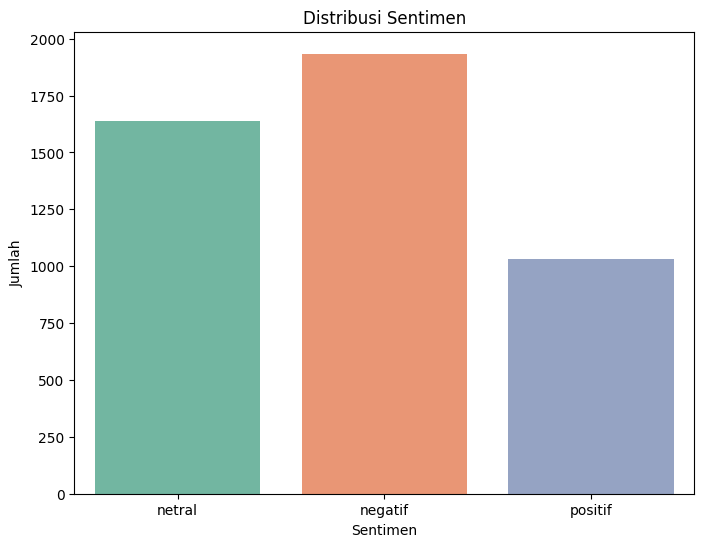

In [195]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sentimen', data=df, palette='Set2')
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

In [196]:
sentiment_texts = {
    'negatif': negative,
    'netral': neutral,
    'positif': positive
}

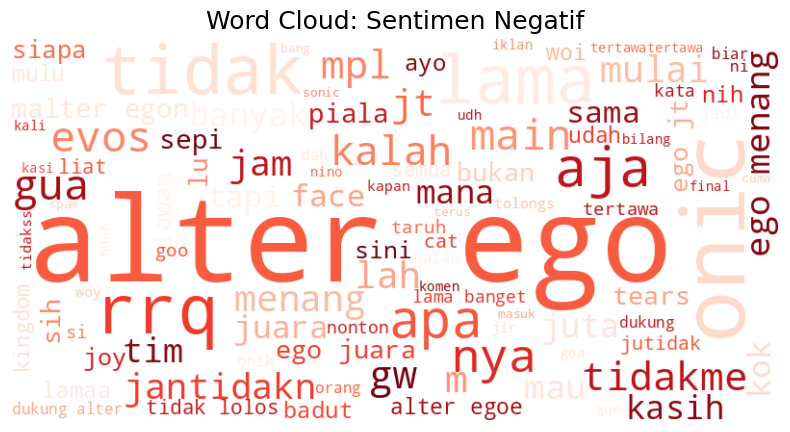

In [197]:
# wordcloud sentimen negatif
wordcloud_negatif = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(negative)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negatif, interpolation='bilinear')
plt.title('Word Cloud: Sentimen Negatif', fontsize=18)
plt.axis('off')
plt.show()

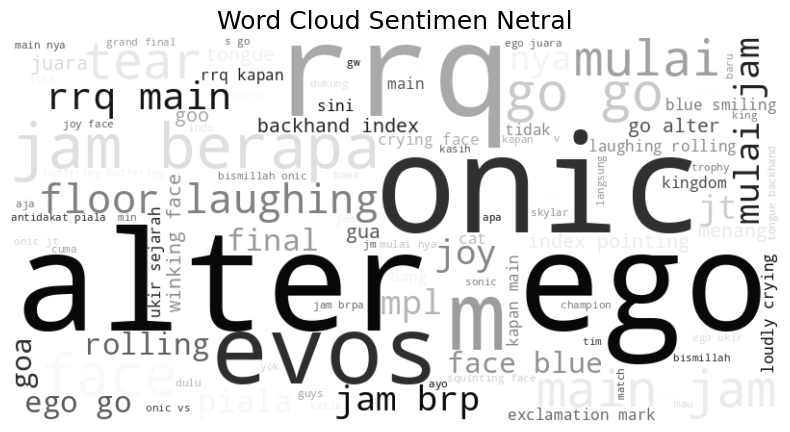

In [198]:
# wordcloud netral
wordcloud_netral = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greys',
    max_words=100
).generate(neutral)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_netral, interpolation='bilinear')
plt.title('Word Cloud Sentimen Netral', fontsize=18)
plt.axis('off')
plt.show()

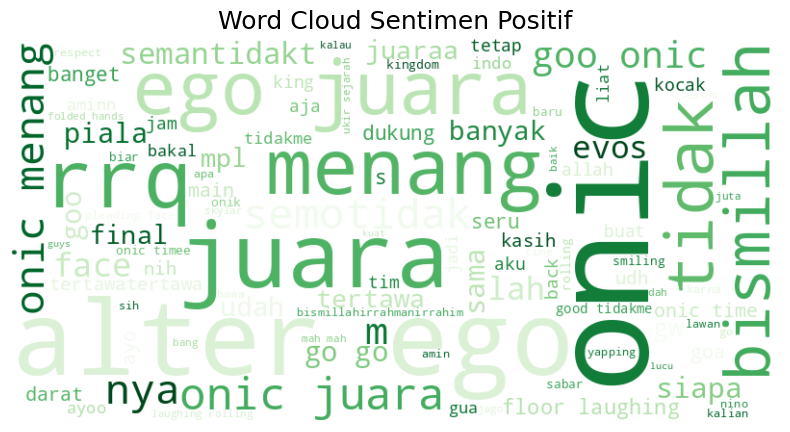

In [199]:
# wordcloud positif
wordcloud_positif = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positif, interpolation='bilinear')
plt.title('Word Cloud Sentimen Positif', fontsize=18)
plt.axis('off')
plt.show()

In [200]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X = vectorizer.fit_transform(df['message_clean'])
y = df['sentimen']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [201]:
svm_model_2 = SVC(
    kernel='linear',
    C=1.0,
    decision_function_shape='ovr',
    class_weight='balanced'
)
svm_model_2.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear')

In [202]:
y_pred = svm_model_2.predict(X_test)
target_names = ['Negatif', 'Netral', 'Positif']
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))

Akurasi Model: 0.7328990228013029
              precision    recall  f1-score   support

     Negatif       0.78      0.75      0.76       387
      Netral       0.77      0.70      0.73       328
     Positif       0.62      0.76      0.68       206

    accuracy                           0.73       921
   macro avg       0.72      0.74      0.73       921
weighted avg       0.74      0.73      0.73       921



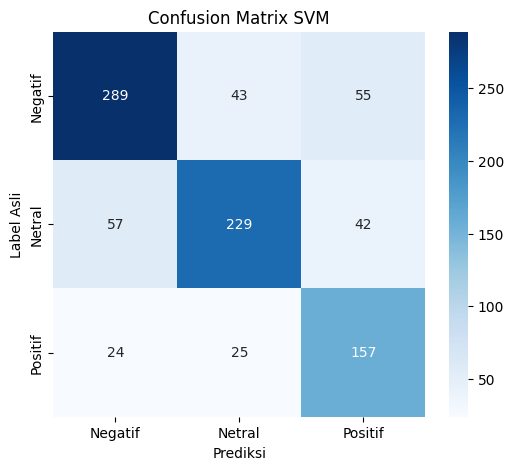

In [203]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif', 'Netral', 'Positif'],
    yticklabels=['Negatif', 'Netral', 'Positif']
)
plt.xlabel('Prediksi')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix SVM')
plt.show()